# DATA EXPLORATION 
Goal of this notebook is to study MNIST DATASET and infer its properties to help set up MLP training model

In [193]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

#Loading test and train data csv files
train_data=pd.read_csv('MNIST_CSV/mnist_train.csv', header=None)
test_data=pd.read_csv('MNIST_CSV/mnist_test.csv', header=None)

## Basic Properties
Study train test split, data dimentions, data types, image resolution, number of classes and its distrinution

### Train Test Split
Study split ratio and overlap

In [194]:
# Finding the split ratio of the data

Length_of_train_data=len(train_data)
Length_of_test_data=len(test_data)

print("Length of train data is ",Length_of_train_data)
print("Length of test data is ",Length_of_test_data)
print("Split ratio of the data is ",Length_of_test_data/Length_of_train_data)    

# Overlapping of the data

Combined_dataset=pd.concat([train_data, test_data], ignore_index=True)
print('No Duplicates found') if Combined_dataset.duplicated().sum()==0 else f'Number of duplicates: {Combined_dataset.duplicated().sum()==0}' 


Length of train data is  60000
Length of test data is  10000
Split ratio of the data is  0.16666666666666666
No Duplicates found


### Dimentions
study the shape, samples, features, and pixel counts

In [195]:
# Samples of Train data

print(train_data.head())
print(train_data.tail())

   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    5    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    1    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    9    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]
       0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
59995    8    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59996    3    0    0    0    0    0    0    0    0    0  ...    0    0    0   
59997    5    0    0    0    0    0    0    0    0    

In [196]:
# Samples of Test data

print(test_data.head())
print(test_data.tail())

   0    1    2    3    4    5    6    7    8    9    ...  775  776  777  778  \
0    7    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
1    2    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
2    1    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
3    0    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   
4    4    0    0    0    0    0    0    0    0    0  ...    0    0    0    0   

   779  780  781  782  783  784  
0    0    0    0    0    0    0  
1    0    0    0    0    0    0  
2    0    0    0    0    0    0  
3    0    0    0    0    0    0  
4    0    0    0    0    0    0  

[5 rows x 785 columns]
      0    1    2    3    4    5    6    7    8    9    ...  775  776  777  \
9995    2    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9996    3    0    0    0    0    0    0    0    0    0  ...    0    0    0   
9997    4    0    0    0    0    0    0    0    0    0  .

In [ ]:
print('=== Dimensions of Training Dataset ===')

# 1. Shape of Data
print('Shape: ', train_data.shape)

# 2. Number of samples
print('Samples: ', len(train_data[0]))

# 3. Number of features
print('Features: ', len(train_data.columns)-1)

# 4. Label column information
print('Number of classes: ', len(train_data[0].unique()))
print('Classes values: ',sorted(train_data[0].unique()))

# 5. Memory used
print('Memory used: ', train_data.memory_usage().sum()/ 1024**2 , 'MB')


=== Dimentions of Training Dataset ===
Shape:  (60000, 785)
Samples:  60000
Features:  784
Number of classes:  10
Classes values:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Memory used:  359.34460830688477 MB


In [ ]:
print('=== Dimensions of Test Dataset ===')

# 1. Shape of Data
print('Shape: ', test_data.shape)

# 2. Number of samples
print('Samples: ', len(test_data[0]))

# 3. Number of features
print('Features: ', len(test_data.columns)-1)

# 4. Label column information
print('Number of classes: ', len(test_data[0].unique()))
print('Classes values: ',sorted(test_data[0].unique()))

# 5. Memory used
print('Memory used: ', test_data.memory_usage().sum()/ 1024**2 , 'MB')

=== Dimentions of Test Dataset ===
Shape:  (10000, 785)
Samples:  10000
Features:  784
Number of classes:  10
Classes values:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Memory used:  59.890872955322266 MB


## Class distribution
Study the frequency and distributions of classes in Training data

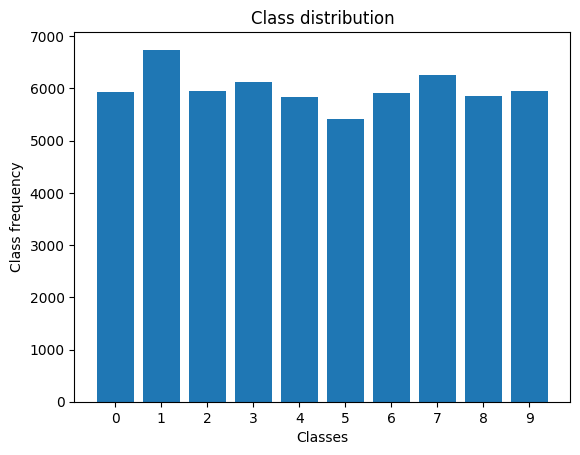

In [ ]:
# Frequency of classes and its distributions in Training data

classes, count= np.unique(train_data.iloc[:,0].values, return_counts=True)

class_frequency= dict(zip(classes, count))

plt.title('Class distribution')
plt.xlabel('Classes')
plt.ylabel('Class frequency')
plt.bar(class_frequency.keys(), class_frequency.values(), )
plt.xticks(list(class_frequency.keys()))
plt.show()

Class distribution is even across classses

# Image properties

Resolution (28x28, but confirm it)
Pixel value range (0-255 or 0-1?)
Data type (uint8, float?)
Shape of a single sample

In [200]:
# 1. Total Pixels
print('Pixels: ', len(train_data.columns)-1)

# 2. Image resolution
side=int(math.sqrt(len(train_data.columns)-1))
print('Resolution: ', f'{side}X{side}')

# 2. Pixel intensity
print(f'Maximum pixel intensity: ({train_data.values.min()},{train_data.values.max()})')

# 3. Data Type 
print('Label data type: ',train_data.iloc[0,0].dtype)

# 4. Shape of individual samples
print('Shape of each sample :', train_data.iloc[0].shape)

Pixels:  784
Resolution:  28X28
Maximum pixel intensity: (0,255)
Label data type:  int64
Shape of each sample : (785,)


# Visualising few samples

Plotting histograms of a few digits to visualise the image data

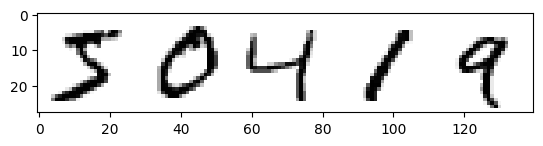

In [237]:
# Creating a heat map of first 5 digits together
train_data_heatmaps =train_data.iloc[:5,1:].to_numpy().reshape(-1,28,28)

plt.imshow(np.hstack(train_data_heatmaps),cmap='gray_r')

plt.show()

# Exploring Correlation between Lable and the lengths of bright pixels in each sample
Studying correlation between number of bright pixels in a sample and the label values

### Studying correlation between length of bright pixels and labels

In [ ]:
# defining bright pixels
brightness= 255//2

# Calculating bright pixels
bright_pixels_data = [sum(1 if i > brightness else 0 for i in rows[1] ) for rows in train_data.iloc[:,1:].iterrows()]

bright_pixels_df = pd.DataFrame({'labels':train_data.iloc[:,0],'values':bright_pixels_data})

bright_pixels_avg = bright_pixels_df.groupby(['labels'],as_index=False).mean()

bright_pixels_dict = dict(zip(bright_pixels_avg.iloc[1:,0], bright_pixels_avg.iloc[1:,1]))

print(bright_pixels_dict)

{1: 60.205428656185106, 2: 118.23044645854314, 3: 112.45685858750612, 4: 95.94334132146525, 5: 102.16343847998525, 6: 109.0909090909091, 7: 90.69545091779729, 8: 119.61801401469835, 9: 97.30677424777274}


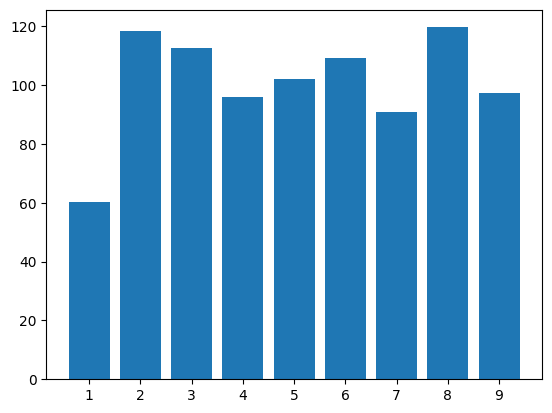

In [ ]:
# visualizing using bar graph

plt.xticks(list(bright_pixels_dict.keys()))

plt.bar(bright_pixels_dict.keys(), bright_pixels_dict.values())

plt.show()

## Using alternative ways to deal with close bar values

close groups - 

* 4, 7, 9 : Trying to adjust weights of bright pixels close to center and bright pixels in bottom half
* 2, 3 : Trying to adjust weights of bright pixels close to center and bright pixels in bottom half
* 5, 6 : Trying to adjust weights of bright pixels close to center and bright pixels in bottom half

Using the bright pixels close to the center as additional weight given the skewness of bright pixels around the center in numbers with close bar values

In [ ]:
# finding all the middle pixels
start_of_middle = np.arange(394,784,28)

additive = np.arange(9,19)

chosen_pixels = (start_of_middle[:,None] + additive).flatten()

chosen_pixels_set = set(chosen_pixels)

# Giving additional 30% weightage to central cum bright pixels
bright_pixels_center_data = [sum(1+(2 if n >394 else 0) + (-2 if n in chosen_pixels_set else 0)if i > brightness else 0 for n,i in enumerate(rows[1]) ) for rows in train_data.iloc[:,1:].iterrows()]

bright_pixel_center_df = pd.DataFrame({'labels':train_data.iloc[:,0],'values':bright_pixels_center_data})

bright_pixel_center_avg = bright_pixel_center_df.groupby(['labels'],as_index=False).mean()

bright_pixel_center_dict = dict(zip(bright_pixel_center_avg.iloc[1:,0], bright_pixel_center_avg.iloc[1:,1]))

print(bright_pixel_center_dict)


{1: 68.4412637199644, 2: 170.4147364887546, 3: 143.8944707225575, 4: 123.2672030126669, 5: 132.66998708725328, 6: 148.06928016221696, 7: 101.51939345570631, 8: 149.64570158947188, 9: 115.41099344427634}


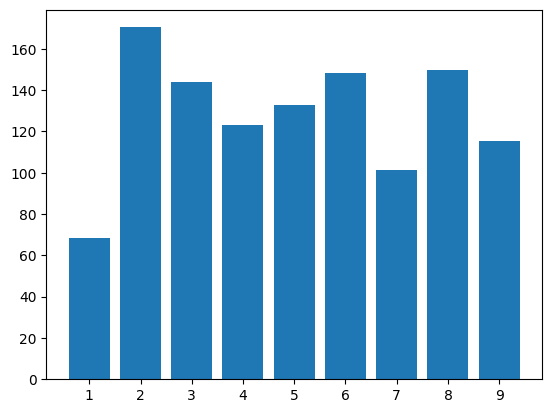

In [ ]:
# visualizing our bright cum central method distribution 

plt.xticks(list(bright_pixels_dict.keys()))

plt.bar(bright_pixel_center_dict.keys(), bright_pixel_center_dict.values())

plt.show()


### Concluions
* 4, 7, 9 : Bar graph relative change is noticible
* 2, 3 : Bar graph relative change is noticible
* 5, 6 : Bar graph relative change is noticible

## Testing the correlation in test data
Using the pixel length and placement to determine the accuracy of our prediction

In [ ]:
# Dictionary storing the weight values corresponding to each label 

correlation_dict = bright_pixel_center_dict

test_data_weights = [sum(1+(2 if n >394 else 0) + (-2 if n in chosen_pixels_set else 0) if i > brightness else 0 for n,i in enumerate(rows[1]) ) for rows in test_data.iloc[:,1:].iterrows()]

actual_labels = np.array(test_data.iloc[:,0])

bright_pixel_center_values= np.array(list(bright_pixel_center_dict.values()))

# Finding predicted classes
predictions = np.abs(bright_pixel_center_values[:,None]-test_data_weights).argmin(axis=0)

predictions_labels = predictions.flatten() + 1

# computing accuracy
accurate_prediction_count = ((predictions_labels - actual_labels)==0).sum()

accuracy= accurate_prediction_count/len(predictions_labels)*100

print (accuracy)

22.36


## Conclusions

22.36 percent accuracy shows that bright pixel count and general distrubution is not an accurate way to predict digit. 
Use of MLP is needed to improve accuracy.